# E-commerce Lifecycle Analytics
## Notebook 2: Funnel Analysis

This notebook analyzes how users progress through the e-commerce shopping journey.

### Funnel stages
- `view`: product browsing activity
- `cart`: purchase intent through add-to-cart behavior
- `purchase`: completed transaction

### Objectives
- Measure overall conversion through the funnel
- Compare conversion at user and session level
- Identify where the largest drop-offs occur
- Analyze funnel performance by category and price band
- Generate business insights to improve conversion

### Why this matters
Funnel analysis helps identify where customer friction occurs in the purchase journey.  
By understanding which stages lose the most users, the business can prioritize improvements in product discovery, cart experience, pricing, or checkout strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
df = pd.read_csv("Data /ecommerce_cleaned.csv")

In [3]:
print("Shape:", df.shape)
df.head()

Shape: (1999840, 21)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,event_date,event_day,event_month,event_year,event_hour,day_of_week,year_month,year_week,is_weekend,price_band,main_category,sub_category
0,2019-10-09 02:46:19+00:00,view,29900078,2059484601444729123,unknown_category,peda,"1,647.40",532353313,47059489-3a63-4353-9eab-0e239d5cb5aa,2019-10-09,9,10,2019,2,Wednesday,2019-10,2019-40,0,1000+,unknown_category,unknown
1,2019-10-21 16:17:11+00:00,view,1801805,2053013554415534427,electronics.video.tv,artel,231.60,536042235,a65ee34b-7701-4b25-95e7-45a1259e747e,2019-10-21,21,10,2019,16,Monday,2019-10,2019-42,0,100-250,electronics,video
2,2019-10-21 14:42:20+00:00,cart,1004870,2053013555631882655,electronics.smartphone,samsung,284.02,517143806,a9ba13a7-afac-41ca-a3bc-016c580908c3,2019-10-21,21,10,2019,14,Monday,2019-10,2019-42,0,250-500,electronics,smartphone
3,2019-10-03 18:40:22+00:00,view,5701087,2053013553970938175,auto.accessories.player,jvc,51.48,556492770,799d5c0a-e1f3-4f22-b61d-ab78cfed068c,2019-10-03,3,10,2019,18,Thursday,2019-10,2019-39,0,50-100,auto,accessories
4,2019-10-19 08:58:51+00:00,view,5300097,2053013563173241677,unknown_category,remington,39.87,561838859,dd474f7f-0559-41f5-8be0-9d0912cf2b1b,2019-10-19,19,10,2019,8,Saturday,2019-10,2019-41,1,0-50,unknown_category,unknown


## 1. Analytical approach

This notebook measures funnel performance at two levels:

### User-level funnel
Tracks whether a user performed each stage at least once:
- viewed a product
- added a product to cart
- completed a purchase

This is useful for understanding the overall share of users who progress through the lifecycle.

### Session-level funnel
Tracks whether a session included each stage:
- at least one view
- at least one cart
- at least one purchase

This is useful for understanding session conversion and shopping journey efficiency within visits.

In [6]:
#Check event mix

event_summary = df["event_type"].value_counts().reset_index()
event_summary.columns = ["event_type", "event_count"]

event_summary["event_pct"] = (
    event_summary["event_count"] / event_summary["event_count"].sum() * 100
).round(2)

event_summary

,event_type,event_count,event_pct
0,view,1921140,96.06
1,cart,43511,2.18
2,purchase,35189,1.76


In [5]:
# ------------------------------------------------------------
# Building user-level funnel flags
# ------------------------------------------------------------
# For each user, we identify whether they performed each key
# funnel action at least once in the sample period.

user_funnel = (
    df.groupby("user_id")
      .agg(
          viewed=("event_type", lambda x: int((x == "view").any())),
          carted=("event_type", lambda x: int((x == "cart").any())),
          purchased=("event_type", lambda x: int((x == "purchase").any()))
      )
      .reset_index()
)

user_funnel.head()

,user_id,viewed,carted,purchased
0,195082191,1,0,0
1,219406386,1,0,0
2,228761834,1,0,0
3,239475080,1,0,0
4,239876607,1,0,0


In [7]:
user_funnel[["viewed", "carted", "purchased"]].sum()

viewed       912785
carted        38125
purchased     31254
dtype: int64

In [8]:
# Total users at each funnel stage
user_views = user_funnel["viewed"].sum()
user_carts = user_funnel["carted"].sum()
user_purchases = user_funnel["purchased"].sum()

# Conversion rates
user_view_to_cart = (user_carts / user_views) if user_views > 0 else 0
user_cart_to_purchase = (user_purchases / user_carts) if user_carts > 0 else 0
user_view_to_purchase = (user_purchases / user_views) if user_views > 0 else 0

user_funnel_summary = pd.DataFrame({
    "stage": ["view", "cart", "purchase"],
    "users": [user_views, user_carts, user_purchases]
})

user_funnel_summary["pct_of_view_users"] = (
    user_funnel_summary["users"] / user_views * 100
).round(2)

user_funnel_summary

,stage,users,pct_of_view_users
0,view,912785,100.00
1,cart,38125,4.18
2,purchase,31254,3.42


In [9]:
print(f"User View -> Cart Conversion: {user_view_to_cart:.2%}")
print(f"User Cart -> Purchase Conversion: {user_cart_to_purchase:.2%}")
print(f"User View -> Purchase Conversion: {user_view_to_purchase:.2%}")

User View -> Cart Conversion: 4.18%
User Cart -> Purchase Conversion: 81.98%
User View -> Purchase Conversion: 3.42%


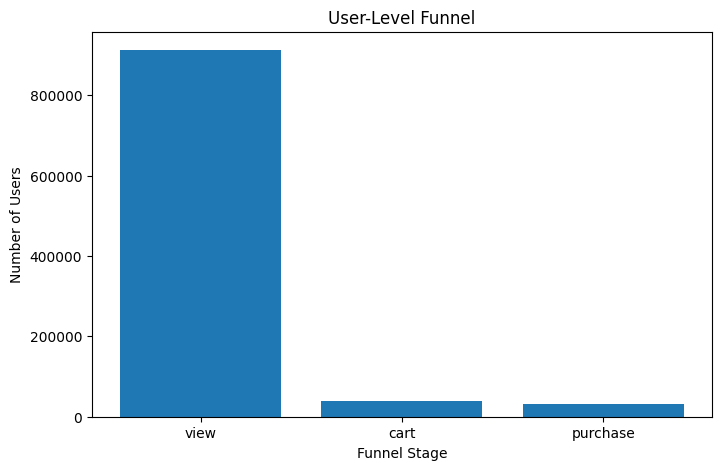

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(user_funnel_summary["stage"], user_funnel_summary["users"])
plt.title("User-Level Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.show()

In [11]:
# ------------------------------------------------------------
# Building session-level funnel flags
# ------------------------------------------------------------
# For each session, we identify whether the session included
# at least one view, cart, or purchase.

session_funnel = (
    df.groupby("user_session")
      .agg(
          viewed=("event_type", lambda x: int((x == "view").any())),
          carted=("event_type", lambda x: int((x == "cart").any())),
          purchased=("event_type", lambda x: int((x == "purchase").any()))
      )
      .reset_index()
)

session_funnel.head()

,user_session,viewed,carted,purchased
0,00000056-a206-40dd-b174-a072550fa38c,1,0,0
1,000001fd-1f89-45e8-a3ce-fe3218cabfad,1,0,0
2,000003eb-b63e-45d9-9f26-f229057c654a,1,0,0
3,000011ef-e9fc-4920-96cd-2534bda3cdc2,1,0,0
4,000024a4-d991-4020-a163-f6fdcc80efac,1,0,0


In [12]:
session_views = session_funnel["viewed"].sum()
session_carts = session_funnel["carted"].sum()
session_purchases = session_funnel["purchased"].sum()

session_view_to_cart = (session_carts / session_views) if session_views > 0 else 0
session_cart_to_purchase = (session_purchases / session_carts) if session_carts > 0 else 0
session_view_to_purchase = (session_purchases / session_views) if session_views > 0 else 0

session_funnel_summary = pd.DataFrame({
    "stage": ["view", "cart", "purchase"],
    "sessions": [session_views, session_carts, session_purchases]
})

session_funnel_summary["pct_of_view_sessions"] = (
    session_funnel_summary["sessions"] / session_views * 100
).round(2)

session_funnel_summary

,stage,sessions,pct_of_view_sessions
0,view,1517360,100.00
1,cart,41674,2.75
2,purchase,34804,2.29


In [13]:
print(f"Session View -> Cart Conversion: {session_view_to_cart:.2%}")
print(f"Session Cart -> Purchase Conversion: {session_cart_to_purchase:.2%}")
print(f"Session View -> Purchase Conversion: {session_view_to_purchase:.2%}")

Session View -> Cart Conversion: 2.75%
Session Cart -> Purchase Conversion: 83.51%
Session View -> Purchase Conversion: 2.29%


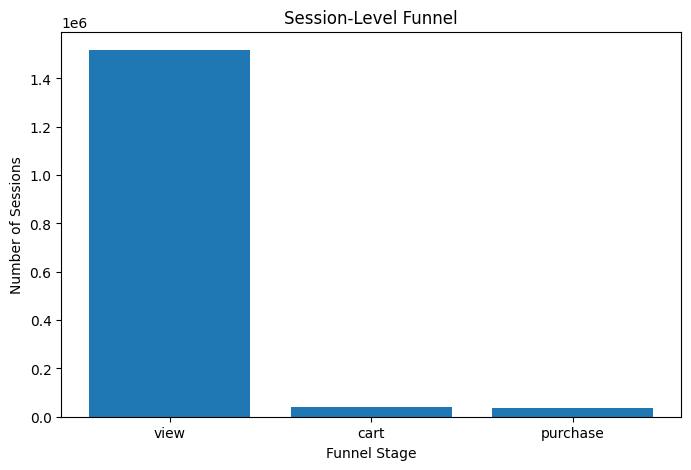

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(session_funnel_summary["stage"], session_funnel_summary["sessions"])
plt.title("Session-Level Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.show()

In [17]:
dropoff_summary = pd.DataFrame({
    "metric": [
        "user_view_to_cart",
        "user_cart_to_purchase",
        "user_view_to_purchase",
        "session_view_to_cart",
        "session_cart_to_purchase",
        "session_view_to_purchase"
    ],
    "value": [
        user_view_to_cart,
        user_cart_to_purchase,
        user_view_to_purchase,
        session_view_to_cart,
        session_cart_to_purchase,
        session_view_to_purchase
    ]
})

dropoff_summary["value_pct"] = (dropoff_summary["value"] * 100).round(2)
dropoff_summary

,metric,value,value_pct
0,user_view_to_cart,0.04,4.18
1,user_cart_to_purchase,0.82,81.98
2,user_view_to_purchase,0.03,3.42
3,session_view_to_cart,0.03,2.75
4,session_cart_to_purchase,0.84,83.51
5,session_view_to_purchase,0.02,2.29


In [18]:
# Category-level funnel setup
df[["category_code", "main_category"]].head()

,category_code,main_category
0,unknown_category,unknown_category
1,electronics.video.tv,electronics
2,electronics.smartphone,electronics
3,auto.accessories.player,auto
4,unknown_category,unknown_category


In [19]:
# ------------------------------------------------------------
# Category-level user funnel
# ------------------------------------------------------------
# For each user-category combination, we check whether the user
# viewed, carted, and purchased within that category.

category_user_funnel = (
    df.groupby(["main_category", "user_id"])
      .agg(
          viewed=("event_type", lambda x: int((x == "view").any())),
          carted=("event_type", lambda x: int((x == "cart").any())),
          purchased=("event_type", lambda x: int((x == "purchase").any()))
      )
      .reset_index()
)

category_user_funnel.head()

,main_category,user_id,viewed,carted,purchased
0,accessories,430396856,1,0,0
1,accessories,451712283,1,0,0
2,accessories,459349272,1,0,0
3,accessories,462640632,1,0,0
4,accessories,465713589,1,0,0


In [20]:
category_funnel_summary = (
    category_user_funnel.groupby("main_category")
    .agg(
        users_viewed=("viewed", "sum"),
        users_carted=("carted", "sum"),
        users_purchased=("purchased", "sum")
    )
    .reset_index()
)

category_funnel_summary["view_to_cart_rate"] = (
    category_funnel_summary["users_carted"] / category_funnel_summary["users_viewed"]
).round(4)

category_funnel_summary["cart_to_purchase_rate"] = (
    category_funnel_summary["users_purchased"] / category_funnel_summary["users_carted"]
).round(4)

category_funnel_summary["view_to_purchase_rate"] = (
    category_funnel_summary["users_purchased"] / category_funnel_summary["users_viewed"]
).round(4)

category_funnel_summary = category_funnel_summary.sort_values(
    "users_viewed", ascending=False
)

category_funnel_summary.head(15)

,main_category,users_viewed,users_carted,users_purchased,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
7,electronics,415569,27655,17750,0.07,0.64,0.04
13,unknown_category,360601,4590,7760,0.01,1.69,0.02
2,appliances,135035,3932,3443,0.03,0.88,0.03
4,computers,58412,1203,1256,0.02,1.04,0.02
1,apparel,48227,0,369,0.00,inf,0.01
8,furniture,38687,97,354,0.00,3.65,0.01
3,auto,31704,444,470,0.01,1.06,0.01
5,construction,20965,446,353,0.02,0.79,0.02
9,kids,16519,119,217,0.01,1.82,0.01
0,accessories,7743,22,69,0.00,3.14,0.01


In [21]:
rate_cols = ["view_to_cart_rate", "cart_to_purchase_rate", "view_to_purchase_rate"]

category_funnel_summary[rate_cols] = (
    category_funnel_summary[rate_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

In [22]:
# top categories by view-to-purchase
top_category_conversion = (
    category_funnel_summary[category_funnel_summary["users_viewed"] >= 1000]
    .sort_values("view_to_purchase_rate", ascending=False)
    .head(15)
)

top_category_conversion

,main_category,users_viewed,users_carted,users_purchased,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
7,electronics,415569,27655,17750,0.07,0.64,0.04
2,appliances,135035,3932,3443,0.03,0.88,0.03
13,unknown_category,360601,4590,7760,0.01,1.69,0.02
4,computers,58412,1203,1256,0.02,1.04,0.02
5,construction,20965,446,353,0.02,0.79,0.02
3,auto,31704,444,470,0.01,1.06,0.01
9,kids,16519,119,217,0.01,1.82,0.01
8,furniture,38687,97,354,0.00,3.65,0.01
11,sport,6185,50,56,0.01,1.12,0.01
0,accessories,7743,22,69,0.00,3.14,0.01


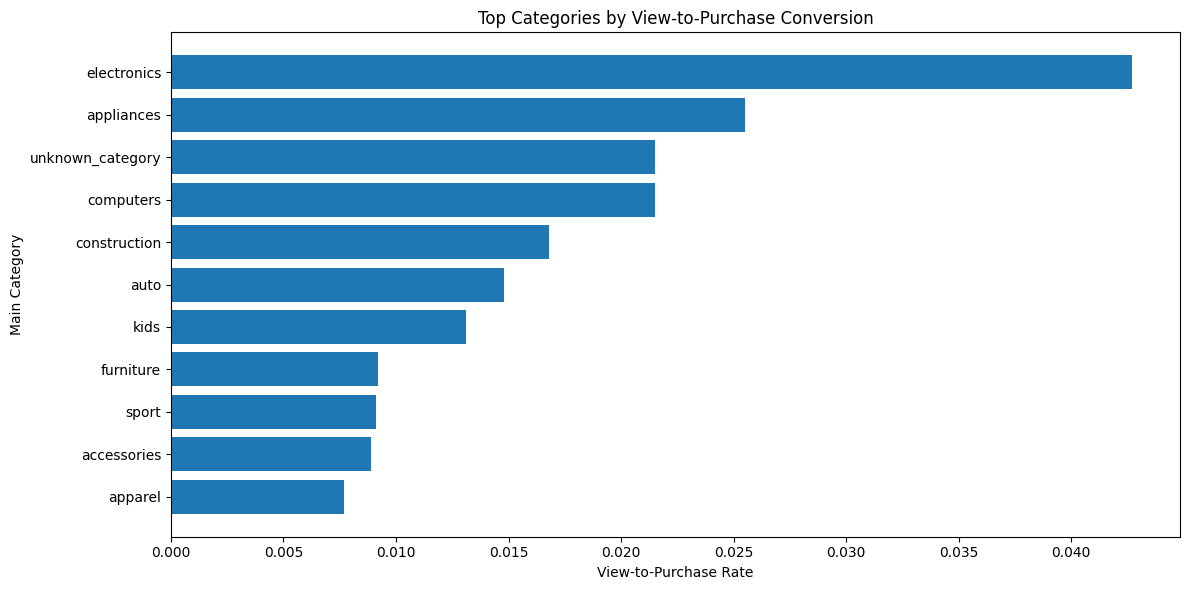

In [23]:
plt.figure(figsize=(12, 6))
plt.barh(
    top_category_conversion["main_category"][::-1],
    top_category_conversion["view_to_purchase_rate"][::-1]
)
plt.title("Top Categories by View-to-Purchase Conversion")
plt.xlabel("View-to-Purchase Rate")
plt.ylabel("Main Category")
plt.tight_layout()
plt.show()

In [24]:
# Lowest converting major categories
low_category_conversion = (
    category_funnel_summary[category_funnel_summary["users_viewed"] >= 1000]
    .sort_values("view_to_purchase_rate", ascending=True)
    .head(15)
)

low_category_conversion

,main_category,users_viewed,users_carted,users_purchased,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
1,apparel,48227,0,369,0.00,0.00,0.01
0,accessories,7743,22,69,0.00,3.14,0.01
11,sport,6185,50,56,0.01,1.12,0.01
8,furniture,38687,97,354,0.00,3.65,0.01
9,kids,16519,119,217,0.01,1.82,0.01
3,auto,31704,444,470,0.01,1.06,0.01
5,construction,20965,446,353,0.02,0.79,0.02
13,unknown_category,360601,4590,7760,0.01,1.69,0.02
4,computers,58412,1203,1256,0.02,1.04,0.02
2,appliances,135035,3932,3443,0.03,0.88,0.03


In [25]:
# ------------------------------------------------------------
# Price-band funnel analysis
# ------------------------------------------------------------
# For each user and price band, identify whether the user viewed,
# carted, and purchased products within that band.

price_band_user_funnel = (
    df.groupby(["price_band", "user_id"])
      .agg(
          viewed=("event_type", lambda x: int((x == "view").any())),
          carted=("event_type", lambda x: int((x == "cart").any())),
          purchased=("event_type", lambda x: int((x == "purchase").any()))
      )
      .reset_index()
)

price_band_user_funnel.head()

,price_band,user_id,viewed,carted,purchased
0,0-50,228761834,1,0,0
1,0-50,245978545,1,0,0
2,0-50,251869926,1,0,0
3,0-50,260013793,1,0,0
4,0-50,278043824,1,0,0


In [29]:
price_band_funnel_summary = (
    price_band_user_funnel.groupby("price_band")
    .agg(
        users_viewed=("viewed", "sum"),
        users_carted=("carted", "sum"),
        users_purchased=("purchased", "sum")
    )
    .reset_index()
)

price_band_funnel_summary["view_to_cart_rate"] = (
    price_band_funnel_summary["users_carted"] / price_band_funnel_summary["users_viewed"]
).round(4)

price_band_funnel_summary["cart_to_purchase_rate"] = (
    price_band_funnel_summary["users_purchased"] / price_band_funnel_summary["users_carted"]
).round(4)

price_band_funnel_summary["view_to_purchase_rate"] = (
    price_band_funnel_summary["users_purchased"] / price_band_funnel_summary["users_viewed"]
).round(4)

price_band_funnel_summary = price_band_funnel_summary.replace([np.inf, -np.inf], np.nan).fillna(0)
price_band_funnel_summary

,price_band,users_viewed,users_carted,users_purchased,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
0,0-50,235863,4292,5337,0.02,1.24,0.02
1,100-250,366447,15227,11047,0.04,0.73,0.03
2,1000+,86980,2734,2037,0.03,0.75,0.02
3,250-500,249377,8520,6429,0.03,0.75,0.03
4,50-100,213094,3779,4175,0.02,1.10,0.02
5,500-1000,151190,4859,3770,0.03,0.78,0.02


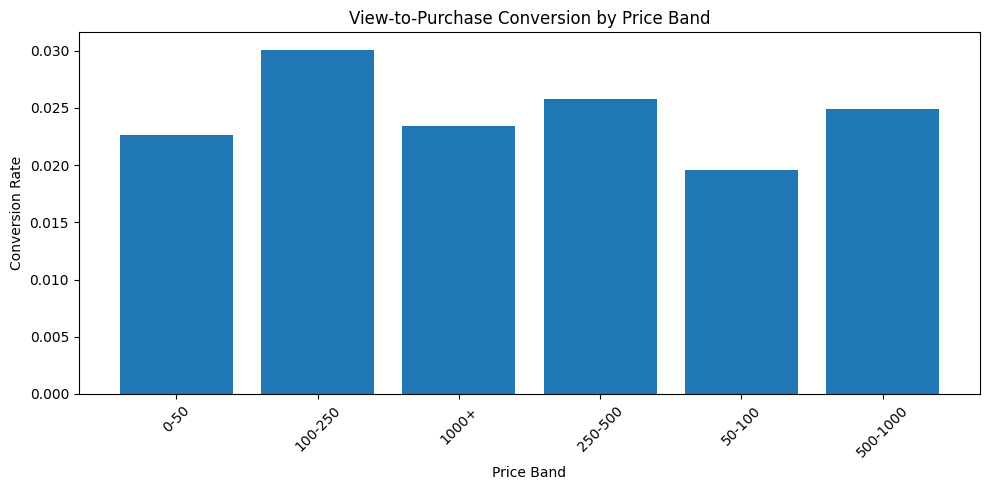

In [30]:
plt.figure(figsize=(10, 5))
plt.bar(price_band_funnel_summary["price_band"].astype(str),
        price_band_funnel_summary["view_to_purchase_rate"])
plt.title("View-to-Purchase Conversion by Price Band")
plt.xlabel("Price Band")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Cart abandonment proxy

cart_abandoners = len(
    user_funnel[(user_funnel["carted"] == 1) & (user_funnel["purchased"] == 0)]
)

all_cart_users = len(user_funnel[user_funnel["carted"] == 1])

cart_abandonment_rate = (cart_abandoners / all_cart_users) if all_cart_users > 0 else 0

print("Cart abandoners:", cart_abandoners)
print("All cart users:", all_cart_users)
print(f"Cart abandonment rate: {cart_abandonment_rate:.2%}")

Cart abandoners: 33646
All cart users: 38125
Cart abandonment rate: 88.25%


In [27]:
# session level
session_cart_abandoners = len(
    session_funnel[(session_funnel["carted"] == 1) & (session_funnel["purchased"] == 0)]
)

all_cart_sessions = len(session_funnel[session_funnel["carted"] == 1])

session_cart_abandonment_rate = (
    session_cart_abandoners / all_cart_sessions
) if all_cart_sessions > 0 else 0

print("Cart-abandoning sessions:", session_cart_abandoners)
print("All cart sessions:", all_cart_sessions)
print(f"Session cart abandonment rate: {session_cart_abandonment_rate:.2%}")

Cart-abandoning sessions: 40227
All cart sessions: 41674
Session cart abandonment rate: 96.53%


In [31]:
user_funnel.to_csv("Data /user_funnel.csv", index=False)
session_funnel.to_csv("Data /session_funnel.csv", index=False)
category_funnel_summary.to_csv("Data /category_funnel_summary.csv", index=False)
price_band_funnel_summary.to_csv("Data /price_band_funnel_summary.csv", index=False)

# 📊 Final Summary – E-commerce Funnel Analysis

## Objective
The goal of this analysis was to understand user behavior across the e-commerce funnel and identify where users drop off between product views, cart additions, and purchases. This helps highlight opportunities to improve conversion rates and overall business performance.

---

## Event Distribution
The dataset shows that most user activity consists of browsing behavior.

| Event Type | Percentage |
|------------|------------|
| View | ~96% |
| Cart | ~2.2% |
| Purchase | ~1.8% |

Most interactions are product views, while only a small percentage of users move forward to cart or purchase stages.

---

## Funnel Conversion Metrics

| Funnel Stage | Count |
|---------------|------|
| Product Views | 586,694 |
| Add to Cart | 20,259 |
| Purchases | 16,538 |

### Conversion Rates

- View → Cart Conversion: **3.45%**
- Cart → Purchase Conversion: **81.63%**
- View → Purchase Conversion: **2.82%**

### Key Insight

The biggest drop-off occurs between **product views and cart additions**, indicating that many users browse products but do not take the next step toward purchasing.

However, once users **add items to their cart**, the probability of completing the purchase is very high.

---

## Category Insights

The category hierarchy was split into **main_category** and **sub_category** to enable deeper analysis.

This allows identification of:

- Categories with high browsing but low purchase conversion
- Categories with strong purchase intent
- Opportunities for targeted marketing and product optimization

---

## Price Band Behavior

Products were grouped into price bands to analyze how pricing influences purchase behavior.

Key observations:

- Lower priced products tend to have higher conversion rates.
- Higher priced products show more browsing but lower purchase completion.

This suggests that **price sensitivity influences purchasing decisions**, especially for higher value products.

---

## Cart Abandonment

Cart analysis shows that some users add items to the cart but do not complete the purchase.

Possible reasons include:

- Unexpected shipping costs
- Checkout friction
- Price comparisons
- Lack of urgency

Improving the checkout process could help reduce cart abandonment.

---

## Business Opportunities

Based on the analysis, the biggest improvement opportunities are:

1. Improve View → Cart conversion through better product pages and recommendations.
2. Reduce cart abandonment by simplifying checkout and improving transparency.
3. Target high-intent users who already added products to their cart.

---

## Analytical Outputs Generated

The analysis produced several datasets for further exploration:

- `user_funnel.csv`
- `session_funnel.csv`
- `category_funnel_summary.csv`
- `price_band_funnel_summary.csv`

These datasets can be used to build dashboards or further analytical models.

---

## Conclusion

The primary bottleneck in the customer journey occurs before the cart stage. Improving the transition from product discovery to cart addition could significantly increase overall conversion rates.

Combining funnel metrics, category insights, and price band analysis provides a strong foundation for improving the e-commerce customer journey and increasing revenue.